# 17B. Frozen MERT + LR 선택

동결된 MERT의 13개 layer를 각각 768차원 입력으로 사용하고 LR의 C 다섯 값을 비교했다. scaler와 분류기는 Train에만 맞추고 Validation Track EER로 layer·C·임계값을 골랐다. Test 결과는 공동 평가 23번에 있다.

## 1. 환경과 실행 설정

MERT는 외부 사전학습 모델이므로 from-scratch CNN과 동일한 학습 정보량을 갖지 않는다. 같은 평가 기준은 같은 계산 예산을 뜻하지 않는다. 패키지 버전, 모델 revision, 입력 설정, 장비와 시간을 함께 저장한다.

학습은 Python/NumPy/PyTorch seed 42를 사용한다. 단일 seed가 모든 장비에서 완전 동일한 결과를 보장하지는 않는다. 필요한 패키지가 없으면 기존 17번의 환경 안내를 참고하고 **같은 커널**에서 실행한다.

In [1]:
# MERT revision·실행 환경·난수 상태를 기록하고 Test와 분리된 작업 경로를 만든다.
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import os
import random
import sys
import time
import warnings

import joblib
import librosa
import numpy as np
import pandas as pd
import torch
import transformers

# 현재 작업 디렉터리가 프로젝트 루트인지 확인해 잘못된 파일 접근을 막는다.
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data/metadata/segment_manifest_10s.csv").exists():
    raise FileNotFoundError("프로젝트 루트에서 노트북을 실행하세요.")
sys.path.insert(0, str(PROJECT_ROOT))
from src.mert_modeling import (
    load_frozen_mert,
    embedding_cache_metadata,
    extract_embedding_cache,
)

RUN_ID = "mert_binary_" + datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
SEED = 42
MODEL_NAME = "m-a-p/MERT-v1-95M"
MODEL_REVISION = "12af15fef9d0ac838c3f475bfbbf26d2060dd4f5"
SR = 24_000
SEGMENT_SEC = 10.0
LAYERS = list(range(13))
C_VALUES = [0.01, 0.1, 1.0, 10.0, 100.0]
BASELINE_KEY = (12, 1.0)
RESULT_DIR = PROJECT_ROOT / "results/model_tuning"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints/optimized"
CACHE_DIR = PROJECT_ROOT / "data/processed/mert"
for path in (RESULT_DIR, CHECKPOINT_DIR, CACHE_DIR):
    path.mkdir(parents=True, exist_ok=True)

# Python·NumPy·PyTorch 난수 시드를 같은 값으로 기록한다.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
# MERT_FORCE_CPU=1이면 CNN의 MPS 사용과 겹치지 않게 CPU를 선택한다.
DEVICE = torch.device(
    "cpu"
    if os.environ.get("MERT_FORCE_CPU") == "1"
    else (
        "cuda"
        if torch.cuda.is_available()
        else (
            "mps"
            if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
            else "cpu"
        )
    )
)
print("Run:", RUN_ID, "| Device:", DEVICE)
print(
    "Versions:",
    {
        "python": sys.version.split()[0],
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "torch": torch.__version__,
        "transformers": transformers.__version__,
        "librosa": librosa.__version__,
    },
)

Run: mert_binary_20260919T110741Z | Device: cpu
Versions: {'python': '3.13.9', 'numpy': '2.3.5', 'pandas': '2.3.3', 'torch': '2.14.0', 'transformers': '4.47.1', 'librosa': '1.0.0'}


실행 run_id는 `mert_binary_20260919T110741Z`이고 장비는 CPU였다. Python 3.13.9, PyTorch 2.14.0, Transformers 4.47.1, librosa 1.0.0을 사용했다. seed는 42로 고정했다.

이 기록은 이후 checkpoint와 결과 CSV가 어느 실행 환경에서 만들어졌는지 확인하는 기준이다.

seed 42만으로 장비·라이브러리가 다른 환경의 결과까지 완전히 같다고 보장할 수 없다. 이 단계에서는 데이터나 성능을 평가하지 않았다.

## 2. Manifest 및 누수 검사

동일 original_audio의 모든 REAL/FAKE track과 segment는 한 split에 있어야 한다. 중복 ID, label 불일치, 누락 입력은 모델 실행을 멈추고 원인을 보고한다. Test의 **성능이나 score는 읽지 않는다**. Manifest는 split 무결성 검사에만 사용한다. Train/Validation의 class 개수는 segment·track·original_audio 단위로 기록한다.

In [2]:
# 원곡 그룹 분리와 Train/Validation class 수를 확인하고 Test row를 학습에서 제외한다.
MANIFEST_PATH = PROJECT_ROOT / "data/metadata/segment_manifest_10s.csv"
manifest_hash = hashlib.sha256(MANIFEST_PATH.read_bytes()).hexdigest()
# 기존 manifest만 읽고 split을 새로 만들지 않는다.
manifest = pd.read_csv(MANIFEST_PATH)
required = {
    "segment_id",
    "track_sample_id",
    "original_audio",
    "label",
    "label_id",
    "split",
    "audio_path",
    "start_sec",
}
missing = required - set(manifest.columns)
if missing:
    raise ValueError(f"Manifest 필수 컬럼 누락: {sorted(missing)}")
if manifest["segment_id"].isna().any() or manifest["segment_id"].duplicated().any():
    raise ValueError("segment_id 결측 또는 중복")
if (
    manifest[["track_sample_id", "original_audio", "audio_path", "start_sec", "split"]]
    .isna()
    .any()
    .any()
):
    raise ValueError("Manifest ID, 경로, 시작 시각 또는 split 결측")
if not np.isfinite(pd.to_numeric(manifest["start_sec"], errors="coerce")).all():
    raise ValueError("Manifest 시작 시각 오류")
# 같은 원곡의 표본이 여러 분할에 섞이지 않도록 저장된 split을 그대로 사용한다.
if not manifest["split"].isin(["train", "val", "test"]).all():
    raise ValueError("알 수 없는 split")
if not (
    (manifest["label"].eq("REAL") & manifest["label_id"].eq(0))
    | (manifest["label"].eq("FAKE") & manifest["label_id"].eq(1))
).all():
    raise ValueError("REAL=0/FAKE=1 mapping 불일치")
# 같은 원곡의 파생 track/segment가 split 사이에 섞이면 중단한다.
if (manifest.groupby("original_audio")["split"].nunique() > 1).any():
    raise ValueError("original_audio가 여러 split에 걸침")
if (
    manifest.groupby("track_sample_id")[["label_id", "original_audio", "split"]]
    .nunique()
    .gt(1)
    .any()
    .any()
):
    raise ValueError("track 안의 label/original_audio/split 불일치")

# 모델링용 행은 Train/Validation으로 제한한다. Test 성능은 읽지 않는다.
work = manifest.loc[manifest["split"].isin(["train", "val"])].reset_index(drop=True)
train_idx = np.flatnonzero(work["split"].to_numpy() == "train")
val_idx = np.flatnonzero(work["split"].to_numpy() == "val")
if not len(train_idx) or not len(val_idx):
    raise ValueError("Train 또는 Validation이 비어 있음")
for split_name, group in work.groupby("split"):
    print(
        split_name,
        "segments",
        group.groupby("label").size().to_dict(),
        "tracks",
        group.drop_duplicates("track_sample_id").groupby("label").size().to_dict(),
        "original_audio",
        group.groupby("label")["original_audio"].nunique().to_dict(),
    )
print("Manifest SHA256:", manifest_hash)
print("Train/Val segment IDs:", len(work), work["segment_id"].nunique())

train segments {'FAKE': 6346, 'REAL': 621} tracks {'FAKE': 2185, 'REAL': 207} original_audio {'FAKE': 207, 'REAL': 207}
val segments {'FAKE': 1406, 'REAL': 132} tracks {'FAKE': 483, 'REAL': 44} original_audio {'FAKE': 44, 'REAL': 44}
Manifest SHA256: 9023dcb21bef5d7163c63ea93258195e53c9fde3ecb7fee5920bf6ff94bbc2b3
Train/Val segment IDs: 8505 8505


Train은 Segment REAL 621 / FAKE 6,346개, Track REAL 207 / FAKE 2,185개였고, Validation은 Segment REAL 132 / FAKE 1,406개, Track REAL 44 / FAKE 483개였다. Train/Validation segment_id 8,505개가 모두 고유했다. Manifest SHA256은 `9023dcb21bef5d7163c63ea93258195e53c9fde3ecb7fee5920bf6ff94bbc2b3`이다.

FAKE가 다수이므로 모든 LR 후보에 `class_weight="balanced"`를 적용하고, 평가에서는 클래스별 오류와 Macro-F1도 함께 본다. original_audio의 split 중복, track 내 label 불일치, 결측 ID 검사도 통과했다.

Validation REAL track은 44개로 적어 작은 성능 차이를 일반화하지 않는다. 이 검사는 split 무결성을 확인한 것이며 원본 오디오의 출처 차이를 제거하지 않는다.

## 3. MERT 로딩과 유효 frame 평균

공식 processor의 sampling_rate를 확인한다. 각 10초 구간에서 실제로 읽힌 waveform만 MERT에 넣는다. 짧은 마지막 segment에 0을 붙이지 않으므로 encoder 출력의 모든 frame이 유효하다. 한 segment씩 추론하여 batch padding도 없다. 이 방식은 기존 v2 cache의 padding 포함 평균과 다르므로 **기존 embedding cache를 재사용하지 않는다**. hidden_states 각 tensor의 시간축 평균을 내어 layer마다 768차원으로 만든다.

In [3]:
# 사전학습 MERT 가중치를 동결하고 공식 processor의 24 kHz 입력 규약을 확인한다.
# 고정 revision의 사전학습 encoder를 불러와 모든 가중치를 동결한다.
processor, encoder, DEVICE, model_load_sec = load_frozen_mert(
    device=DEVICE, model_name=MODEL_NAME, revision=MODEL_REVISION
)
# 이 환경에서는 MERT 로드 뒤에 sklearn을 import해야 원격 모델 코드 충돌을 피한다.
import sklearn
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from src.modeling_evaluation import evaluate_binary_predictions, select_best_candidate

print("scikit-learn version:", sklearn.__version__)
print(
    "Encoder:",
    MODEL_NAME,
    MODEL_REVISION,
    "| frozen:",
    all(not p.requires_grad for p in encoder.parameters()),
)
print(
    "Processor sampling_rate:",
    processor.sampling_rate,
    "| load sec:",
    round(model_load_sec, 2),
)

scikit-learn version: 1.7.2
Encoder: m-a-p/MERT-v1-95M 12af15fef9d0ac838c3f475bfbbf26d2060dd4f5 | frozen: True
Processor sampling_rate: 24000 | load sec: 0.31


고정 revision `12af15fef9d0ac838c3f475bfbbf26d2060dd4f5`의 MERT-v1-95M을 CPU에 로드했다. 공식 processor의 sampling rate는 24,000 Hz이고 encoder parameter는 모두 frozen이었다. 로드 시간은 0.31초였다.

사전학습 표현을 고정한 채 layer별 768차원 벡터를 비교하므로, 탐색에서 바뀌는 것은 layer와 Logistic Regression의 C다.

출력된 `nnAudio` 경고는 선택적 CQT 기능 관련 경고이며 이번 waveform 입력의 MERT forward는 이어서 성공했다. 모델 로드 성공만으로 전체 embedding 품질이나 탐지 성능을 판단하지 않는다.

## 4. Train/Validation embedding cache

새 cache는 segment_id 순서, model revision, processor 입력 설정, valid-frame pooling, manifest hash를 metadata로 고정한다. 중단 시 완료 mask로 재개한다. 같은 layer의 모든 C는 **같은 embedding**을 사용한다. Cache는 Test 행을 포함하지 않는다.

In [4]:
# manifest/segment 순서/입력 설정 해시를 저장해 잘못된 cache 재사용을 막는다.
cache_meta = embedding_cache_metadata(work, MANIFEST_PATH, MODEL_NAME, MODEL_REVISION)
print(
    "Cache identity:",
    cache_meta["segment_ids_sha256"][:16],
    cache_meta["revision"][:12],
    cache_meta["pooling"],
)

Cache identity: 03e0c45bc24f6514 12af15fef9d0 single-segment valid hidden frames mean


새 cache의 segment 순서 해시 접두사는 `03e0c45bc24f6514`, 모델 revision 접두사는 `12af15fef9d0`이었다. Pooling 규약은 `single-segment valid hidden frames mean`으로 기록됐다.

segment ID 순서와 모델·입력 설정이 cache metadata에 묶여 있어 다른 조건의 embedding을 같은 cache로 읽는 실수를 막는다.

이 metadata 검사 자체는 embedding 추출 완료나 성능을 뜻하지 않는다. 기존 v2 cache는 padding 처리와 provenance가 달라 이번 실행에 재사용하지 않았다.

In [5]:
# 완료 mask를 사용해 중단된 Train/Validation 추출만 재개한다.
embeddings, DEVICE, embedding_extract_sec, cache_paths, actual_cache_meta = (
    extract_embedding_cache(
        frame=work,
        project_root=PROJECT_ROOT,
        manifest_path=MANIFEST_PATH,
        cache_dir=CACHE_DIR,
        cache_tag="binary_train_val",
        processor=processor,
        encoder=encoder,
        device=DEVICE,
        model_name=MODEL_NAME,
        revision=MODEL_REVISION,
    )
)
if actual_cache_meta != cache_meta:
    raise ValueError("MERT cache metadata 불일치")
META_PATH = cache_paths["metadata"]
print("Train/Validation embedding cache:", cache_paths["embeddings"])
print("Extraction sec this run:", round(embedding_extract_sec, 2))

MERT cache: 50 / 8505
MERT cache: 100 / 8505
MERT cache: 150 / 8505
MERT cache: 200 / 8505
MERT cache: 250 / 8505
MERT cache: 300 / 8505
MERT cache: 350 / 8505
MERT cache: 400 / 8505
MERT cache: 450 / 8505
MERT cache: 500 / 8505
MERT cache: 550 / 8505
MERT cache: 600 / 8505
MERT cache: 650 / 8505
MERT cache: 700 / 8505
MERT cache: 750 / 8505
MERT cache: 800 / 8505
MERT cache: 850 / 8505
MERT cache: 900 / 8505
MERT cache: 950 / 8505
MERT cache: 1000 / 8505
MERT cache: 1050 / 8505
MERT cache: 1100 / 8505
MERT cache: 1150 / 8505
MERT cache: 1200 / 8505
MERT cache: 1250 / 8505
MERT cache: 1300 / 8505
MERT cache: 1350 / 8505
MERT cache: 1400 / 8505
MERT cache: 1450 / 8505
MERT cache: 1500 / 8505
MERT cache: 1550 / 8505
MERT cache: 1600 / 8505
MERT cache: 1650 / 8505
MERT cache: 1700 / 8505
MERT cache: 1750 / 8505
MERT cache: 1800 / 8505
MERT cache: 1850 / 8505
MERT cache: 1900 / 8505
MERT cache: 1950 / 8505
MERT cache: 2000 / 8505
MERT cache: 2050 / 8505
MERT cache: 2100 / 8505
MERT cache: 

Train/Validation **8,505/8,505개 segment**의 MERT embedding 추출이 완료됐다. CPU 추출 시간은 **4,000.93초**였고 cache shape는 각 segment의 13개 level × 768차원이다. 완료 mask에서도 8,505개 모두 확인됐다.

이제 같은 segment와 동일한 layer embedding을 모든 C 후보가 재사용할 수 있다. 짧은 마지막 segment는 0을 붙이지 않고 실제 입력에서 나온 frame만 평균했다.

약 66.7분의 추출 시간은 이 실행 장비·동시 작업 조건에서 측정한 값이다. MERT의 외부 사전학습 비용은 포함하지 않는다. Test embedding은 여기서 추출하지 않았다.

## 5. Layer × C 탐색

C가 작으면 LR의 L2 regularization이 강하고, 크면 약하다. `lbfgs`가 최적화를 수행하므로 learning rate, batch size, epoch를 직접 지정하지 않는다. `max_iter`는 solver의 최대 반복 수이며 CNN epoch와 다르다. 각 layer의 scaler는 Train에서 한 번 fit하여 C 후보 전체에 재사용한다. LR의 `classes_`에서 FAKE=1 열을 확인하고 그 확률을 score로 사용한다.

공통 평가 함수가 Segment score와 track별 산술평균 score를 계산한다. ROC-AUC는 순위 분리력, AP는 average_precision_score 기준의 PR 요약 지표, EER은 FPR/FNR 교점, Balanced Accuracy와 Macro-F1은 불균형을 고려한 분류 지표다. REAL FPR은 REAL을 FAKE로 오탐한 비율, FAKE Miss Rate는 FAKE를 놓친 비율이다. FAKE AP와 REAL AP, 각 split의 class 비율을 함께 해석한다. Validation에서 Segment/Track 임계값을 따로 저장한다.

In [6]:
# Train-only scaler와 balanced LR로 layer×C 후보를 평가하고 Validation에서 선택한다.
def score_frame(metadata, scores):
    """공통 평가 함수에 필요한 ID, label, FAKE score를 같은 순서로 만든다."""
    return pd.DataFrame(
        {
            "segment_id": metadata["segment_id"].astype(str).to_numpy(),
            "track_id": metadata["track_sample_id"].astype(str).to_numpy(),
            "original_audio_id": metadata["original_audio"].astype(str).to_numpy(),
            "label": metadata["label_id"].astype(int).to_numpy(),
            "score": np.asarray(scores, dtype=float),
        }
    )


y_train = work.iloc[train_idx]["label_id"].astype(int).to_numpy()
val_meta = work.iloc[val_idx].reset_index(drop=True)
y_val = val_meta["label_id"].astype(int).to_numpy()
records, artifacts = [], {}
search_start = time.perf_counter()
for layer in LAYERS:
    # layer별 Train scaler를 한 번만 fit; Validation에는 transform만 적용한다.
    X_train = np.asarray(embeddings[train_idx, layer, :], dtype=np.float32)
    X_val = np.asarray(embeddings[val_idx, layer, :], dtype=np.float32)
    if not np.isfinite(X_train).all() or not np.isfinite(X_val).all():
        raise ValueError(f"layer {layer}: nonfinite embedding")
    # 이 layer의 Train 행에서만 평균·분산을 추정한다.
    scaler = StandardScaler()
    # Train의 평균·표준편차를 구하고 같은 Train 행을 변환한다.
    X_train_scaled = scaler.fit_transform(X_train)
    # Validation/Test에는 Train의 표준화 기준만 적용해 정보 누수를 막는다.
    X_val_scaled = scaler.transform(X_val)
    for C in C_VALUES:
        candidate_order = len(records)
        t0 = time.perf_counter()
        # 모든 후보에 동일한 class weighting과 solver를 적용한다.
        classifier = LogisticRegression(
            C=C,
            solver="lbfgs",
            penalty="l2",
            # 클래스별 표본 수가 달라 손실에 기여하는 비중을 조정한다.
            class_weight="balanced",
            max_iter=3000,
            random_state=SEED,
        )
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always", ConvergenceWarning)
            # fit은 모델 계수나 분류 경계를 학습한다. Validation/Test를 여기에 넣지 않는다.
            classifier.fit(X_train_scaled, y_train)
        warning_text = [str(w.message) for w in caught]
        for message in warning_text:
            print(f"layer={layer}, C={C} warning: {message}")
        # classes_에서 FAKE=1 열을 확인하고 해당 확률을 score로 사용한다.
        fake_index = np.flatnonzero(classifier.classes_ == 1)
        if len(fake_index) != 1:
            raise ValueError("LR classes_에 FAKE=1이 없음")
        # 확률 출력에서 모델이 예측한 클래스 순서에 맞는 점수 열을 사용한다.
        val_scores = classifier.predict_proba(X_val_scaled)[:, int(fake_index[0])]
        # 공통 함수로 Segment/Track score와 별도 Validation 임계값을 계산한다.
        evaluated = evaluate_binary_predictions(score_frame(val_meta, val_scores))
        segment, track = evaluated["segment"], evaluated["track"]
        record = {
            "candidate_order": candidate_order,
            "layer": layer,
            "C": C,
            "track_eer": track["eer"],
            "track_roc_auc": track["roc_auc"],
            "val_segment_roc_auc": segment["roc_auc"],
            "val_segment_eer": segment["eer"],
            "val_track_roc_auc": track["roc_auc"],
            "val_track_eer": track["eer"],
            "val_track_macro_f1": track["macro_f1"],
            "fit_sec": time.perf_counter() - t0,
            "convergence_warnings": " | ".join(warning_text),
            "run_id": RUN_ID,
        }
        records.append(record)
        artifacts[(layer, C)] = {
            "scaler": scaler,
            "classifier": classifier,
            "thresholds": evaluated["thresholds"],
            "validation_scores": val_scores,
            "evaluation": evaluated,
        }
        print(
            f"layer={layer:02d} C={C:g} | Val Track EER={track['eer']:.4f} "
            f"AUC={track['roc_auc']:.4f} | {record['fit_sec']:.1f}s"
        )
tuning = pd.DataFrame(records)
if len(tuning) != 65 or not {(r["layer"], r["C"]) for r in records} == set(artifacts):
    raise RuntimeError("MERT 탐색 후보 누락 또는 중복")
# 반올림 전 Track EER→Track AUC→후보 순서로 best를 고른다.
best = select_best_candidate(records)
best_key = (int(best["layer"]), float(best["C"]))
print(
    "Selected:", best_key, "| tuning sec:", round(time.perf_counter() - search_start, 2)
)
display(
    tuning[
        [
            "layer",
            "C",
            "val_segment_roc_auc",
            "val_segment_eer",
            "val_track_roc_auc",
            "val_track_eer",
            "val_track_macro_f1",
            "fit_sec",
            "convergence_warnings",
        ]
    ]
)

layer=00 C=0.01 | Val Track EER=0.1304 AUC=0.9417 | 0.3s
layer=00 C=0.1 | Val Track EER=0.1364 AUC=0.9391 | 0.5s
layer=00 C=1 | Val Track EER=0.1242 AUC=0.9321 | 0.9s
layer=00 C=10 | Val Track EER=0.1591 AUC=0.9195 | 1.4s
layer=00 C=100 | Val Track EER=0.1591 AUC=0.9092 | 1.5s
layer=01 C=0.01 | Val Track EER=0.1136 AUC=0.9610 | 0.2s
layer=01 C=0.1 | Val Track EER=0.1364 AUC=0.9488 | 0.5s
layer=01 C=1 | Val Track EER=0.1364 AUC=0.9417 | 0.8s
layer=01 C=10 | Val Track EER=0.1364 AUC=0.9313 | 1.1s
layer=01 C=100 | Val Track EER=0.1364 AUC=0.9293 | 0.8s
layer=02 C=0.01 | Val Track EER=0.1077 AUC=0.9595 | 0.2s
layer=02 C=0.1 | Val Track EER=0.1136 AUC=0.9521 | 0.4s
layer=02 C=1 | Val Track EER=0.1136 AUC=0.9479 | 0.8s
layer=02 C=10 | Val Track EER=0.1056 AUC=0.9442 | 0.7s
layer=02 C=100 | Val Track EER=0.1056 AUC=0.9362 | 0.5s
layer=03 C=0.01 | Val Track EER=0.1136 AUC=0.9547 | 0.2s
layer=03 C=0.1 | Val Track EER=0.0909 AUC=0.9491 | 0.4s
layer=03 C=1 | Val Track EER=0.1136 AUC=0.9454 | 0.7s

65개 layer×C 후보를 모두 평가했고 수렴 경고는 0개였다. 사전 지정한 Validation Track EER 기준에서 **layer 4, C=0.01**이 선택됐다(Track EER **0.060041**, ROC-AUC **0.965274**). 고정 Baseline인 layer 12, C=1.0의 Track EER는 **0.122153**, ROC-AUC는 **0.948240**이었다.

이번 후보군에서는 강한 L2 regularization에 해당하는 C=0.01과 layer 4 조합의 Track EER가 가장 낮았다. layer 9/C=0.01의 Track ROC-AUC는 0.979108로 더 높지만 EER가 0.068182여서 EER 우선 선택 규칙에 따라 채택되지 않았다.

선택된 설정은 이 search space와 Validation 표본에 대한 결과다. REAL Track이 44개이고, Validation을 반복 탐색에 사용했으므로 이 수치를 최종 일반화 성능으로 해석하지 않는다. Test score는 후보 선택에 사용하지 않았다.

## 6. Baseline과 선택 후보 동결

Baseline은 탐색 전 고정한 layer 12/C=1.0이다. 선택 후보가 Baseline과 같으면 같은 학습 객체와 score를 재사용한다. 두 후보의 Validation Segment/Track 임계값은 각각 저장한다. **여기서 Test 예측이나 결과를 만들지 않는다.** 저장된 Train 학습 모델을 최종 단계에서 그대로 쓰며 Train+Validation 재학습을 하지 않는다.

In [7]:
# Baseline과 선택 후보의 scaler·LR·Validation 임계값을 함께 저장한다.
if BASELINE_KEY not in artifacts or best_key not in artifacts:
    raise RuntimeError("Baseline 또는 best artifact가 없음")


def save_candidate(kind, key):
    """Train 학습 scaler/classifier와 Validation 임계값을 동결한다."""
    item = artifacts[key]
    payload = {
        "run_id": RUN_ID,
        "kind": kind,
        "model": MODEL_NAME,
        "revision": MODEL_REVISION,
        "layer": int(key[0]),
        "C": float(key[1]),
        "scaler": item["scaler"],
        "classifier": item["classifier"],
        "thresholds": item["thresholds"],
        "feature_dim": 768,
        "manifest_sha256": manifest_hash,
        "cache_meta": cache_meta,
        "validation_segment_ids_sha256": hashlib.sha256(
            "\n".join(val_meta["segment_id"].astype(str)).encode()
        ).hexdigest(),
    }
    archive_path = CHECKPOINT_DIR / f"mert_{kind}_{RUN_ID}.joblib"
    path = CHECKPOINT_DIR / f"mert_{kind}.joblib"
    joblib.dump(payload, archive_path)  # run_id별 불변 기록
    joblib.dump(payload, path)  # 최종 평가 단계의 고정 입력 경로
    return path


# 고정 Baseline과 선택 모델을 각각 저장하며 재학습하지 않는다.
baseline_path = save_candidate("baseline", BASELINE_KEY)
best_path = save_candidate("best", best_key)
tuning.to_csv(
    RESULT_DIR / f"mert_tuning_{RUN_ID}.csv", index=False, encoding="utf-8-sig"
)
selected = {
    "run_id": RUN_ID,
    "model": MODEL_NAME,
    "revision": MODEL_REVISION,
    "baseline": {"layer": 12, "C": 1.0, "checkpoint": str(baseline_path)},
    "optimized": {"layer": best_key[0], "C": best_key[1], "checkpoint": str(best_path)},
    "selection": "Validation Track EER min, Track ROC-AUC max, candidate_order",
    "candidate_count": len(tuning),
    "manifest_sha256": manifest_hash,
    "cache_metadata": str(META_PATH),
    "device": str(DEVICE),
    "model_load_sec": model_load_sec,
    "embedding_extract_sec_this_run": embedding_extract_sec,
    "tuning_sec": time.perf_counter() - search_start,
    "versions": {
        "python": sys.version.split()[0],
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "sklearn": sklearn.__version__,
        "torch": torch.__version__,
        "transformers": transformers.__version__,
        "librosa": librosa.__version__,
    },
}
(RESULT_DIR / f"mert_best_config_{RUN_ID}.json").write_text(
    json.dumps(selected, ensure_ascii=False, indent=2), encoding="utf-8"
)
thresholds = {
    "run_id": RUN_ID,
    "baseline": artifacts[BASELINE_KEY]["thresholds"],
    "optimized": artifacts[best_key]["thresholds"],
}
(RESULT_DIR / f"mert_validation_thresholds_{RUN_ID}.json").write_text(
    json.dumps(thresholds, ensure_ascii=False, indent=2), encoding="utf-8"
)
# Validation의 원점수·ID·임계값과 지표를 재현 가능한 CSV로 남긴다.
score_rows, metric_rows = [], []
for kind, key in (("baseline", BASELINE_KEY), ("optimized", best_key)):
    evaluated = artifacts[key]["evaluation"]
    for level in ("segment", "track"):
        metrics = evaluated[level]
        metric_rows.append(
            {
                "run_id": RUN_ID,
                "model": "FrozenMERT+LR",
                "configuration": kind,
                "split": "val",
                "level": level,
                "threshold": evaluated["thresholds"][level],
                "layer": key[0],
                "C": key[1],
                **metrics,
            }
        )
        scores = evaluated[f"{level}_scores"].copy()
        scores.insert(0, "threshold", evaluated["thresholds"][level])
        scores.insert(0, "level", level)
        scores.insert(0, "split", "val")
        scores.insert(0, "configuration", kind)
        scores.insert(0, "model", "FrozenMERT+LR")
        scores.insert(0, "run_id", RUN_ID)
        score_rows.append(scores)
validation_scores = pd.concat(score_rows, ignore_index=True)
validation_scores.to_csv(
    RESULT_DIR / f"mert_validation_scores_{RUN_ID}.csv",
    index=False,
    encoding="utf-8-sig",
)
validation_scores.loc[validation_scores["level"] == "track"].to_csv(
    RESULT_DIR / f"mert_validation_track_scores_{RUN_ID}.csv",
    index=False,
    encoding="utf-8-sig",
)
pd.DataFrame(metric_rows).to_csv(
    RESULT_DIR / f"mert_validation_metrics_{RUN_ID}.csv",
    index=False,
    encoding="utf-8-sig",
)
print("Saved:", baseline_path, best_path)
print("Validation-only outputs:", RESULT_DIR)

Saved: /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/checkpoints/optimized/mert_baseline.joblib /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/checkpoints/optimized/mert_best.joblib
Validation-only outputs: /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/results/model_tuning


## Validation에서 고른 설정 (run_id: mert_binary_20260919T110741Z)

- 새 valid-frame MERT cache에서 Train/Validation **8,505개 segment**를 모두 추출했다(Train 6,967개, Validation 1,538개). CPU 추출은 4,000.93초, 65개 layer×C 후보의 학습·Validation 비교는 27.69초가 걸렸다. 수렴 경고는 0개였다.
- 고정 Baseline은 **layer 12, C=1.0**이고, Validation Track EER가 가장 낮은 후보는 **layer 4, C=0.01**이다. 동률 규칙은 Track ROC-AUC, 그다음 사전 지정 후보 순서다.

| Validation 지표 | Baseline | 선택 후보 |
|---|---:|---:|
| Segment ROC-AUC | 0.9376 | 0.9487 |
| Segment EER | 0.1212 | 0.0909 |
| Track ROC-AUC | 0.9482 | 0.9653 |
| Track EER | 0.1222 | 0.0600 |
| Track Balanced Accuracy | 0.8821 | 0.9359 |
| Track Macro-F1 | 0.7396 | 0.8426 |
| Track REAL FPR | 0.1136 | 0.0682 |
| Track FAKE Miss Rate | 0.1222 | 0.0600 |
| Track REAL AP | 0.8230 | 0.9004 |
| Track FAKE AP | 0.9933 | 0.9922 |

Validation 표본은 Segment REAL 132 / FAKE 1,406개, Track REAL 44 / FAKE 483개다. 선택 후보의 Validation 임계값은 Segment 0.568567, Track 0.588751이며, 두 값은 각각 별도로 고정했다.

이 탐색 범위에서 layer 4/C=0.01은 Baseline보다 Track EER가 약 0.0621 낮고, Track ROC-AUC가 약 0.0170 높았다. Validation 임계값에서 Track REAL FPR과 FAKE Miss Rate도 모두 낮았다. 다만 FAKE AP는 0.9933에서 0.9922로 소폭 낮아졌으므로 모든 지표가 개선된 것은 아니다. 다른 후보인 layer 9/C=0.01은 Track ROC-AUC 0.9791로 더 높지만 Track EER가 0.0682여서, 사전에 정한 **EER 우선** 규칙에 따라 선택되지 않았다. Binary task의 선택 layer는 별도 12-way attribution task의 선택 layer와 달라도 이상하지 않다.

이 설정은 전체 parameter space의 절대 최적값이 아니라 **13개 layer × 5개 C 후보와 Validation Track EER 기준에서 선택된 best configuration**이다. Validation Track은 REAL 44개로 작고, FAKE가 483개로 훨씬 많다. 높은 FAKE AP만으로 불균형 문제가 해결되었다고 해석하지 않는다. FMA REAL과 Echoes TTA FAKE 사이에는 생성 여부 외의 출처·장르·코덱 차이도 반영될 수 있다. MERT는 외부 사전학습을 활용하며 그 데이터와 이번 평가 데이터의 중복 여부는 확인되지 않았다. 기존 17번 노트북의 Test 결과는 과거 실험으로만 보존하며, 이번 Test가 완전히 미사용이었다고 주장하지 않는다.

## 7. Validation 추론 시간 측정

동결된 Baseline/Optimized checkpoint로 **Validation 1,538개 segment**를 다시 예측한다. scaler 변환과 LR `predict_proba`를 함께 10회 반복해 중앙값을 기록한다. 한 번의 warmup 호출은 측정에서 제외한다. 이 시간에는 MERT encoder 추출, 오디오 로딩, Track 평균, CSV 저장이 포함되지 않는다. 이미 저장된 Validation raw score와 재계산 score가 일치하는지도 확인한다.

In [8]:
# 저장된 Validation embedding으로 두 checkpoint의 추론 시간과 점수 일치를 검증한다.
# Test 없이 저장된 Validation embedding과 두 동결 checkpoint만 사용한다.
score_path = RESULT_DIR / f"mert_validation_scores_{RUN_ID}.csv"
score_reference = pd.read_csv(score_path)
inference_rows = []
for configuration, filename in (
    ("baseline", "mert_baseline.joblib"),
    ("optimized", "mert_best.joblib"),
):
    payload = joblib.load(CHECKPOINT_DIR / filename)
    if payload["run_id"] != RUN_ID or payload["manifest_sha256"] != manifest_hash:
        raise ValueError("추론 checkpoint의 실행 ID 또는 manifest가 다름")
    layer = int(payload["layer"])
    X_val_layer = np.asarray(embeddings[val_idx, layer, :], dtype=np.float32)
    fake_index = np.flatnonzero(payload["classifier"].classes_ == 1)
    if len(fake_index) != 1:
        raise ValueError("FAKE=1 확률 열을 찾지 못함")

    def score_once():
        """저장된 Train scaler와 LR로 Validation FAKE score를 계산한다."""
        # 학습된 변환 기준을 다시 fit하지 않고 적용한다.
        scaled = payload["scaler"].transform(X_val_layer)
        # 확률 출력에서 모델이 예측한 클래스 순서에 맞는 점수 열을 사용한다.
        return payload["classifier"].predict_proba(scaled)[:, int(fake_index[0])]

    # 첫 호출로 라이브러리 초기화 영향을 줄이고 저장된 원점수와 일치 여부를 확인한다.
    warmup_score = score_once()
    expected = (
        score_reference.loc[
            (score_reference["configuration"] == configuration)
            & (score_reference["level"] == "segment"),
            ["segment_id", "score"],
        ]
        .set_index("segment_id")
        .loc[val_meta["segment_id"], "score"]
        .to_numpy()
    )
    if not np.allclose(warmup_score, expected, rtol=0, atol=1e-10):
        raise ValueError(f"{configuration}: 저장된 Validation score와 재추론 불일치")

    # 같은 1,538개 segment에 대해 scaler+LR 추론을 10회 측정한다.
    elapsed = []
    for _ in range(10):
        started = time.perf_counter()
        score_once()
        elapsed.append(time.perf_counter() - started)
    inference_rows.append(
        {
            "run_id": RUN_ID,
            "model": "FrozenMERT+LR",
            "configuration": configuration,
            "split": "val",
            "level": "segment",
            "n": len(val_meta),
            "device": "cpu",
            "layer": layer,
            "C": float(payload["C"]),
            "threshold": float(payload["thresholds"]["segment"]),
            "repeats": len(elapsed),
            "median_scaler_lr_inference_sec": float(np.median(elapsed)),
            "mean_scaler_lr_inference_sec": float(np.mean(elapsed)),
        }
    )
inference_timing = pd.DataFrame(inference_rows)
inference_timing.to_csv(
    RESULT_DIR / f"mert_validation_inference_timing_{RUN_ID}.csv",
    index=False,
    encoding="utf-8-sig",
)
print(inference_timing.to_string(index=False))

                      run_id         model configuration split   level    n device  layer    C  threshold  repeats  median_scaler_lr_inference_sec  mean_scaler_lr_inference_sec
mert_binary_20260919T110741Z FrozenMERT+LR      baseline   val segment 1538    cpu     12 1.00   0.986791       10                        0.004702                      0.005047
mert_binary_20260919T110741Z FrozenMERT+LR     optimized   val segment 1538    cpu      4 0.01   0.568567       10                        0.002932                      0.003242


저장된 Train scaler와 LR checkpoint로 Validation **1,538개 segment**를 10회씩 재추론했다. 저장된 raw score와 재계산 score가 일치했다. scaler 변환과 LR `predict_proba`의 중앙값은 Baseline **0.004702초**, Optimized **0.002932초**였다. 각각의 평균은 0.005047초와 0.003242초였다.

이 수치는 이미 추출된 MERT embedding에서 LR head까지의 Validation segment 추론 시간이다. 별도로 측정한 8,505개 embedding 추출 시간은 4,000.93초였으므로 전체 MERT 파이프라인의 계산량을 LR head 시간만으로 설명할 수 없다.

짧은 CPU 타이밍은 다른 작업과 시스템 부하에 민감하다. Baseline/Optimized의 시간 차이를 모델 layer 자체의 보편적 속도 차이로 해석하지 않는다. 이 측정은 오디오 로딩, MERT encoder, Track 평균과 Test 추론을 포함하지 않는다.

## 8. MERT+LR — 저장된 Validation 후보와 Baseline 비교

13개 layer×5개 C 후보의 저장된 Validation 결과를 읽는다. Baseline과 선택 조합의 곡 단위 지표를 비교한다.

설정,MERT layer,LR C,Track ROC-AUC ↑,Track EER ↓,Track Macro-F1 ↑
Baseline,12,1.00,0.9482,0.1222,0.7396
Selected,4,0.01,0.9653,0.0600,0.8426


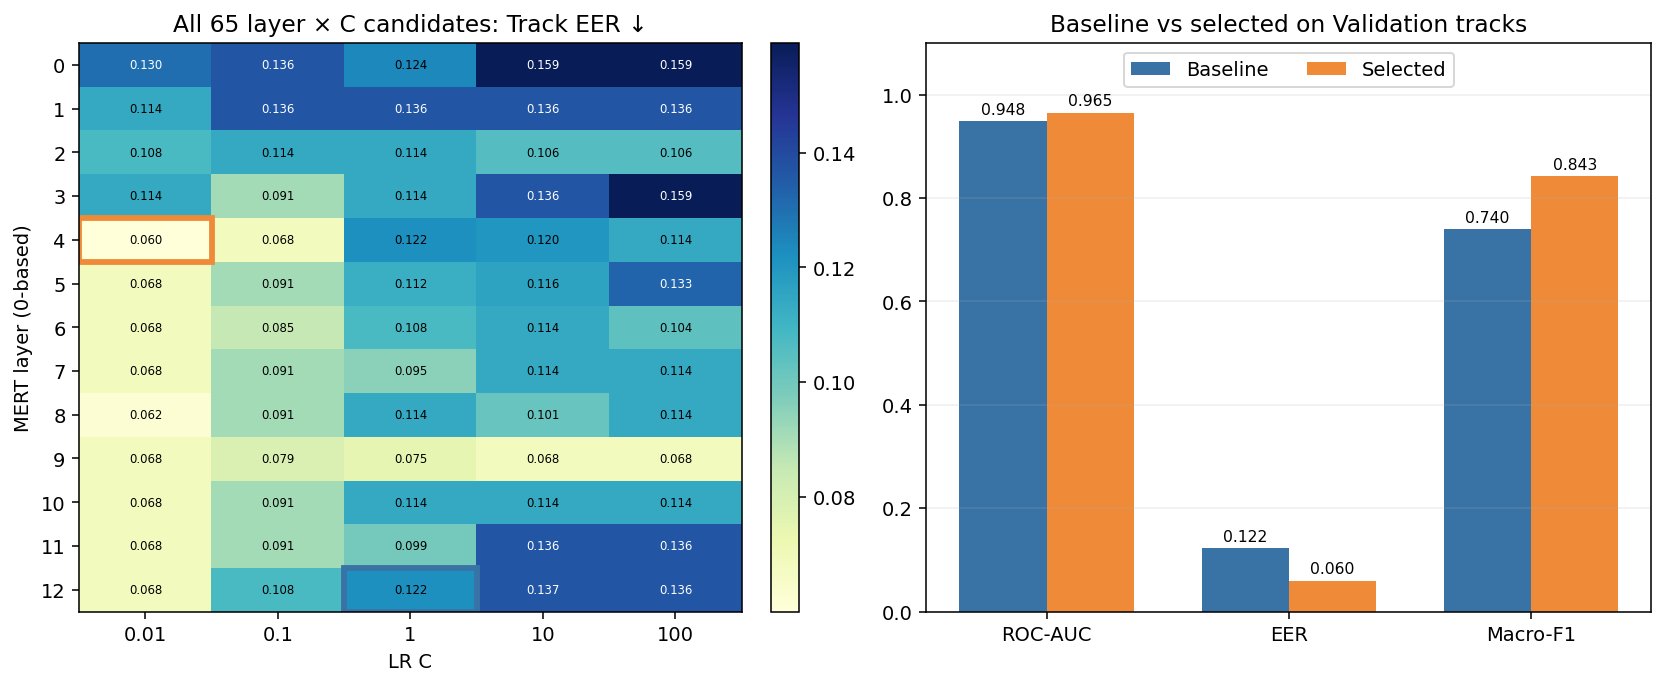

Saved: results/model_tuning/validation_comparisons/mert_validation_comparison.png


In [9]:
# 저장된 후보 결과만 읽는다. 이 셀은 모델을 다시 학습하거나 Test를 열지 않는다.
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

project_root = Path.cwd()
if not (project_root / "results" / "model_tuning").is_dir():
    project_root = project_root.parent
result_dir = project_root / "results" / "model_tuning"
assert result_dir.is_dir(), "프로젝트 루트 또는 archive_notebooks에서 실행하세요."
figure_dir = result_dir / "validation_comparisons"
figure_dir.mkdir(parents=True, exist_ok=True)
config_path = next(result_dir.glob("mert_best_config_mert_binary_*.json"))
config = json.loads(config_path.read_text())
candidates = pd.read_csv(result_dir / f"mert_tuning_{config['run_id']}.csv")
assert len(candidates) == 65 and candidates["run_id"].nunique() == 1
assert candidates["run_id"].iloc[0] == config["run_id"]
baseline_config, selected_config = config["baseline"], config["optimized"]

# layer와 C가 모두 맞는 저장 행을 찾아 Baseline과 선택 후보를 확인한다.
def find_candidate(spec):
    match = candidates.loc[
        (candidates["layer"] == spec["layer"])
        & np.isclose(candidates["C"], spec["C"])
    ]
    assert len(match) == 1
    return match.iloc[0]

baseline = find_candidate(baseline_config)
selected = find_candidate(selected_config)
summary = pd.DataFrame({
    "설정": ["Baseline", "Selected"],
    "MERT layer": [baseline["layer"], selected["layer"]],
    "LR C": [baseline["C"], selected["C"]],
    "Track ROC-AUC ↑": [baseline["val_track_roc_auc"], selected["val_track_roc_auc"]],
    "Track EER ↓": [baseline["val_track_eer"], selected["val_track_eer"]],
    "Track Macro-F1 ↑": [baseline["val_track_macro_f1"], selected["val_track_macro_f1"]],
})
display(summary.round(4))

# 13개 layer × 5개 C 후보의 EER를 열지도로 보여 준다.
c_values = sorted(candidates["C"].unique())
layers = sorted(candidates["layer"].unique())
grid = candidates.pivot(index="layer", columns="C", values="val_track_eer").loc[layers, c_values]
assert grid.notna().all().all()
fig, axes = plt.subplots(1, 2, figsize=(12, 5.0))
image = axes[0].imshow(grid.to_numpy(), cmap="YlGnBu", aspect="auto")
axes[0].set_xticks(range(len(c_values)), [f"{c:g}" for c in c_values])
axes[0].set_yticks(range(len(layers)), layers)
axes[0].set_xlabel("LR C")
axes[0].set_ylabel("MERT layer (0-based)")
axes[0].set_title("All 65 layer × C candidates: Track EER ↓")
for row in range(len(layers)):
    for col in range(len(c_values)):
        value = grid.iloc[row, col]
        axes[0].text(col, row, f"{value:.3f}", ha="center", va="center", fontsize=6, color="white" if value > 0.13 else "black")
from matplotlib.patches import Rectangle
for item, color in [(baseline, "#3973a6"), (selected, "#ef8b38")]:
    row = layers.index(int(item["layer"]))
    col = c_values.index(item["C"])
    axes[0].add_patch(Rectangle((col - 0.5, row - 0.5), 1, 1, fill=False, edgecolor=color, linewidth=3))
fig.colorbar(image, ax=axes[0], fraction=0.046, pad=0.04)
figure_path = figure_dir / "mert_validation_comparison.png"

# 공통 그래프 코드가 읽을 열 이름을 맞춘다.
baseline = pd.Series({"track_roc_auc": baseline["val_track_roc_auc"], "track_eer": baseline["val_track_eer"], "track_macro_f1": baseline["val_track_macro_f1"]})
selected = pd.Series({"track_roc_auc": selected["val_track_roc_auc"], "track_eer": selected["val_track_eer"], "track_macro_f1": selected["val_track_macro_f1"]})
# 같은 Validation Track 지표를 두 설정에서 나란히 비교한다.
metric_names = ["ROC-AUC", "EER", "Macro-F1"]
baseline_values = [baseline["track_roc_auc"], baseline["track_eer"], baseline["track_macro_f1"]]
selected_values = [selected["track_roc_auc"], selected["track_eer"], selected["track_macro_f1"]]
positions = np.arange(len(metric_names))
baseline_bars = axes[1].bar(positions - 0.18, baseline_values, 0.36, label="Baseline", color="#3973a6")
selected_bars = axes[1].bar(positions + 0.18, selected_values, 0.36, label="Selected", color="#ef8b38")
axes[1].bar_label(baseline_bars, fmt="%.3f", padding=2, fontsize=8)
axes[1].bar_label(selected_bars, fmt="%.3f", padding=2, fontsize=8)
axes[1].set_xticks(positions, metric_names)
axes[1].set_ylim(0, 1.10)
axes[1].set_title("Baseline vs selected on Validation tracks")
axes[1].legend(loc="upper center", ncol=2)
axes[1].grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", figure_path.relative_to(project_root))


## 9. MERT+LR — 저장된 공동 Test 비교

저장된 공동 Test 결과의 같은 539곡을 비교한다. AUC·EER은 Test 점수에서 계산했고, Macro-F1·REAL FPR·FAKE miss에는 각 설정의 Validation 임계값을 적용했다. 여기서는 모델이나 임계값을 다시 선택하지 않는다.

설정,Validation threshold,ROC-AUC ↑,EER ↓,Macro-F1 ↑,REAL FPR ↓,FAKE miss ↓
Baseline,0.8848,0.9664,0.0889,0.7515,0.0889,0.1174
Selected,0.5888,0.9845,0.0667,0.8787,0.0889,0.0385


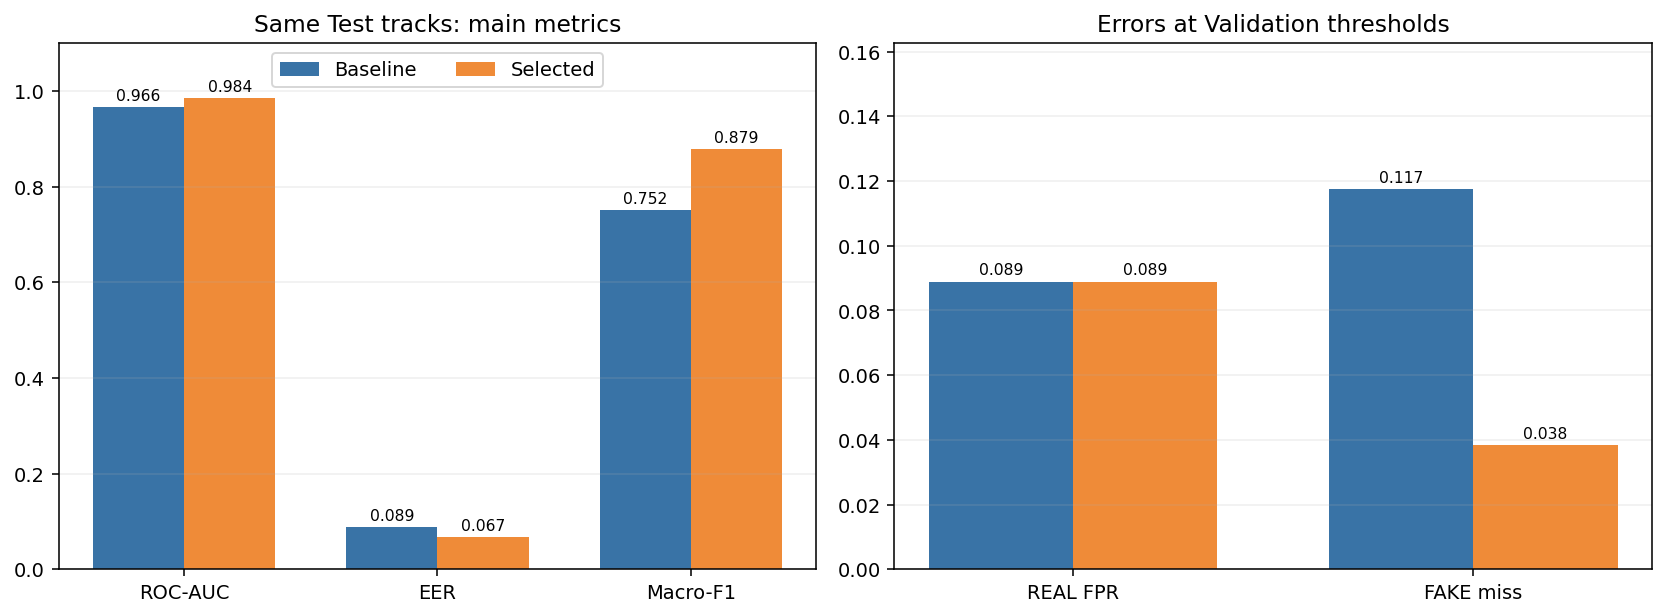

Saved: results/model_tuning/test_comparisons/mert_test_comparison.png


In [10]:
# 저장된 후보 결과만 읽는다. 이 셀은 모델을 다시 학습하거나 Test를 열지 않는다.
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

project_root = Path.cwd()
if not (project_root / "results" / "model_tuning").is_dir():
    project_root = project_root.parent
result_dir = project_root / "results" / "model_tuning"
assert result_dir.is_dir(), "프로젝트 루트 또는 archive_notebooks에서 실행하세요."
figure_dir = result_dir / "validation_comparisons"
figure_dir.mkdir(parents=True, exist_ok=True)
# Validation 후보 그림과 공동 Test 그림은 폴더도 구분해 저장한다.
figure_dir = result_dir / "test_comparisons"
figure_dir.mkdir(parents=True, exist_ok=True)

# 최종 공동 Test CSV에서 이 모델의 곡 단위 두 행만 읽는다.
model_name = 'Frozen MERT + LR'
final_results = pd.read_csv(result_dir / "optimized_test_results.csv")
rows = final_results.loc[
    (final_results["model"] == model_name)
    & (final_results["split"] == "test")
    & (final_results["level"] == "track")
].copy()
assert len(rows) == 2 and set(rows["variant"]) == {"baseline", "optimized"}
expected_run_id = json.loads(next(result_dir.glob("mert_best_config_mert_binary_*.json")).read_text())["run_id"]
assert rows["run_id"].nunique() == 1 and rows["run_id"].iloc[0] == expected_run_id
assert rows["n"].eq(539).all() and rows["n_real"].eq(45).all() and rows["n_fake"].eq(494).all()
baseline = rows.set_index("variant").loc["baseline"]
selected = rows.set_index("variant").loc["optimized"]

# EER과 AUC는 Test 점수에서 계산됐다. 분류 오류율에는 각 설정의 Validation 임계값을 썼다.
summary = pd.DataFrame({
    "설정": ["Baseline", "Selected"],
    "Validation threshold": [baseline["threshold"], selected["threshold"]],
    "ROC-AUC ↑": [baseline["roc_auc"], selected["roc_auc"]],
    "EER ↓": [baseline["eer"], selected["eer"]],
    "Macro-F1 ↑": [baseline["macro_f1"], selected["macro_f1"]],
    "REAL FPR ↓": [baseline["real_fpr"], selected["real_fpr"]],
    "FAKE miss ↓": [baseline["fake_miss_rate"], selected["fake_miss_rate"]],
})
display(summary.round(4))

# 왼쪽은 앞의 Validation 비교와 같은 세 지표, 오른쪽은 오류 방향을 보여 준다.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
main_metrics = [("ROC-AUC", "roc_auc"), ("EER", "eer"), ("Macro-F1", "macro_f1")]
error_metrics = [("REAL FPR", "real_fpr"), ("FAKE miss", "fake_miss_rate")]
for ax, metrics, title in [
    (axes[0], main_metrics, "Same Test tracks: main metrics"),
    (axes[1], error_metrics, "Errors at Validation thresholds"),
]:
    positions = np.arange(len(metrics))
    baseline_values = [baseline[column] for _, column in metrics]
    selected_values = [selected[column] for _, column in metrics]
    baseline_bars = ax.bar(positions - 0.18, baseline_values, 0.36, label="Baseline", color="#3973a6")
    selected_bars = ax.bar(positions + 0.18, selected_values, 0.36, label="Selected", color="#ef8b38")
    ax.bar_label(baseline_bars, fmt="%.3f", padding=2, fontsize=8)
    ax.bar_label(selected_bars, fmt="%.3f", padding=2, fontsize=8)
    ax.set_xticks(positions, [label for label, _ in metrics])
    ax.set_ylim(0, 1.10 if ax is axes[0] else max(baseline_values + selected_values) * 1.3 + 0.01)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.2)
axes[0].legend(loc="upper center", ncol=2)
fig.tight_layout()
figure_path = figure_dir / 'mert_test_comparison.png'
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", figure_path.relative_to(project_root))
